# Model: LightGBM

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

### Objetivo:
> El objetivo de este notebook es entrenar un modelo supervisado que consiga clasificar correctamente a los clientes según el tipo de cluster previamente identificados.

In [41]:
df = pd.read_csv("../data/processed/olist_clustering.csv")

df_scaled = pd.read_csv("../data/processed/olist_scaled_clustering.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  115878 non-null  str    
 1   customer_id               115878 non-null  str    
 2   order_purchase_timestamp  115878 non-null  str    
 3   customer_unique_id        115878 non-null  str    
 4   order_item_id             115878 non-null  float64
 5   product_category_name     115878 non-null  str    
 6   payment_value             115878 non-null  float64
 7   month                     115878 non-null  int64  
 8   day_of_week               115878 non-null  int64  
 9   hour                      115878 non-null  int64  
 10  cluster                   115878 non-null  int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 9.7 MB


In [42]:
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   payment_value          115878 non-null  float64
 1   month                  115878 non-null  float64
 2   hour                   115878 non-null  float64
 3   day_of_week            115878 non-null  float64
 4   product_category_name  115878 non-null  str    
 5   cluster                115878 non-null  int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 5.3 MB


In [43]:
df_scaled["product_category_name"] = df_scaled["product_category_name"].astype("category")
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   payment_value          115878 non-null  float64 
 1   month                  115878 non-null  float64 
 2   hour                   115878 non-null  float64 
 3   day_of_week            115878 non-null  float64 
 4   product_category_name  115878 non-null  category
 5   cluster                115878 non-null  int64   
dtypes: category(1), float64(4), int64(1)
memory usage: 4.5 MB


In [44]:
X = df_scaled[["payment_value", "product_category_name"]]
y = df_scaled["cluster"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
X_train.shape

(92702, 2)

In [46]:
X_test.shape

(23176, 2)

In [47]:
model = lgb.LGBMClassifier(n_estimators=100, max_depth=5, min_child_samples=100, objective="multiclass", num_class="4", force_row_wise=True, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Info] Total Bins 326
[LightGBM] [Info] Number of data points in the train set: 92702, number of used features: 2
[LightGBM] [Info] Start training from score -1.014745
[LightGBM] [Info] Start training from score -1.077690
[LightGBM] [Info] Start training from score -1.213605
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [48]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.40      0.61      0.49      8353
           1       0.42      0.43      0.43      8008
           2       0.38      0.13      0.19      6815

    accuracy                           0.41     23176
   macro avg       0.40      0.39      0.37     23176
weighted avg       0.40      0.41      0.38     23176



Text(0, 0.5, 'Columnas')

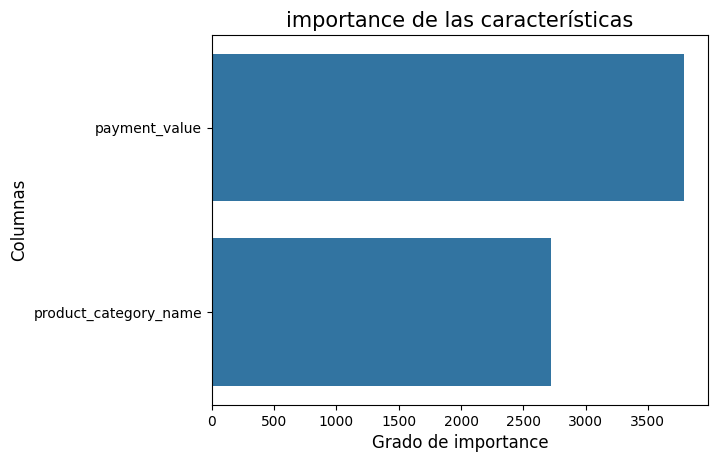

In [49]:
importance = pd.Series(model.feature_importances_, index=X.columns)
sns.barplot(x=importance.values, y=importance.index, order=importance.sort_values(ascending=False).index)
plt.title("importance de las características", fontsize=15)
plt.xlabel("Grado de importance", fontsize=12)
plt.ylabel("Columnas", fontsize=12)


In [50]:
cm = confusion_matrix(y_test, y_pred)

Text(70.72222222222221, 0.5, 'Clase Real (Cluster)')

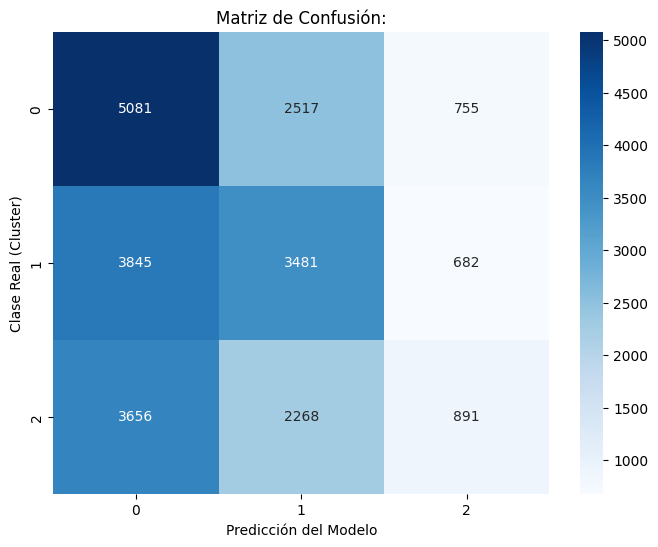

In [51]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión:")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real (Cluster)")

### Observaciones:
> - `591` aciertos para el cluster 0. Hubo 6 casos donde el modelo clasifico erroneamente, que son casos del cluster 0.
> - `7822` aciertos para el cluster 1. Hubo 6 casos donde el modelo clasifico erroneamente, que son casos del cluster 1.
> - `6581` aciertos para el cluster 2. Hubo 4 casos donde el modelo clasifico erroneamente, que son casos del cluster 2.
> - `8163` aciertos para el cluster 3. Hubo 3 casos donde el modelo clasifico erroneamente, que son casos del cluster 3.

## Conclusión:
> El modelo clasifica muy bien los diferentes tipos de clientes.
> Presenta una alta precisión y recall con una puntuación de 1.00 para los cluster 1, 2 y 3, y una puntuación de 0.99 para el cluster número 0.


## Guardar modelo

In [52]:
joblib.dump(model, "../models/lgbm_customer_classifier.pkl")

['../models/lgbm_customer_classifier.pkl']